# STAT 207 Project 02 - Video Game Population Inference

Tara Vittal & Jaclyn Rizzo

## 1. Introduction

This dataset details information about thousands of games, all released betwee 2004-2010. Our dataset shows different Console types, titles of the games released on those consoles, and corresponsnding attributes/variables about the games. Some of the variables include the genre of game, amount of sales (in millions), and release year. There are 166 columns of attributes for each of the games, and there are 5 different console types. 

In [2]:
import pandas as pd
import matplotlib.pyplot as plt     
import seaborn as sns   
sns.set()  

In [3]:
df = pd.read_csv("video_games.csv", encoding="unicode_escape")
df.head()

,Console,Title,US Sales (millions),Block4,Block2,Block1,Block0.5,YearReleased,2004,2005,...,Tricks,Volleyball,Wakeboarding,Wrestling,FirstPerson,Platform,Isometric,SideScrolling,TopDown,ThirdPerson
0,Nintendo DS,Super Mario 64 DS,4.69,1,1,1,1,2004,1,0,...,0,0,0,0,0,1,0,0,0,1
1,Sony PSP,Lumines: Puzzle Fusion,0.56,0,0,0,1,2004,1,0,...,0,0,0,0,0,0,0,0,0,0
2,Nintendo DS,WarioWare Touched!,0.54,0,0,0,1,2004,1,0,...,0,0,0,0,0,1,1,1,1,1
3,Sony PSP,Hot Shots Golf: Open Tee,0.49,0,0,0,0,2004,1,0,...,0,0,0,0,0,0,0,0,0,1
4,Nintendo DS,Spider-Man 2,0.45,0,0,0,0,2004,1,0,...,0,0,0,0,0,1,0,1,0,1


The dataset represents a sample. Not all video games ever released are captured, the data also only shows video games released between 2004-2010. Our population of interest is all video games released with measurable U.S. sales.

We are looking to find the of video games in this dataset that are third person. We will do this by creating at 90% confidence interval to capture a range of reasonable values for the proportion of video games that are third person in the population. We are also looking to see if the population median of US Sales (in millions) is equal to, or different than the sample median of 0.19 by creating a hypothesis test.

Knowing whether the population median of U.S. video game sales is greater than 0.19 million (sample median) helps evaluate how well the market is performing overall. If the median is the same, it could indicate industry stability and consistent consumer demand, while a increase median might suggest a growth in interest in the video games. Similarly, understanding the proportion of third-person games provides insight into player preferences and genre popularity. These results can guide game developers and investors in making smarter decisions about what types of games to create and fund.

## 2. Confidence Interval Analytical Tasks

What is the true proportion of video games that are third person? What is a range of reasonable values for the proportion of video games that are third person in the population?

In [4]:
thirdperson = df[df["ThirdPerson"] == 1]
thirdperson.isna().sum()
thirdperson.describe()

,US Sales (millions),Block4,Block2,Block1,Block0.5,YearReleased,2004,2005,2006,2007,...,Tricks,Volleyball,Wakeboarding,Wrestling,FirstPerson,Platform,Isometric,SideScrolling,TopDown,ThirdPerson
count,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,...,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.000000,1328.0
mean,0.495294,0.011295,0.040663,0.110693,0.228163,2007.433735,0.011295,0.074548,0.163404,0.260542,...,0.018825,0.003012,0.000753,0.010542,0.182229,0.100151,0.037651,0.080572,0.085843,1.0
std,1.083629,0.105717,0.197582,0.313870,0.419806,1.351593,0.105717,0.262760,0.369873,0.439096,...,0.135959,0.054820,0.027441,0.102171,0.386179,0.300314,0.190421,0.272280,0.280238,0.0
min,0.010000,0.000000,0.000000,0.000000,0.000000,2004.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
25%,0.100000,0.000000,0.000000,0.000000,0.000000,2007.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
50%,0.210000,0.000000,0.000000,0.000000,0.000000,2007.000000,0.000000,0.000000,0.000000,0.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
75%,0.470000,0.000000,0.000000,0.000000,0.000000,2008.000000,0.000000,0.000000,0.000000,1.000000,...,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,1.0
max,14.660000,1.000000,1.000000,1.000000,1.000000,2010.000000,1.000000,1.000000,1.000000,1.000000,...,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.000000,1.0


Our sample size is 1328 observations of video games. The numerical summary we chose was the mean. We found that the mean number of US Sales (in millions) in the dataset was 0.495 for third person games. This means there was about 0.495 million sales made for third person video games in the dataset. We also found the sample proportion. The sample proportion of third person video games in this dataset is 0.75. That means that roughly 75% of video games in this dataset are classified as third person games.

In [5]:
samples = []
for i in range(500):
    sample = df.sample(5, replace=True)
    prop = (sample["ThirdPerson"] == 1).sum() / len(sample)
    samples.append(prop)
samples = pd.DataFrame({"proportion": samples})

samples.quantile(0.05), samples.quantile(0.95)

(proportion    0.4
 Name: 0.05, dtype: float64,
 proportion    1.0
 Name: 0.95, dtype: float64)

We are 90% confident that the true proportion of all video games that are third person is captured by the interval 0.4 to 1.

## 3. Hypothesis Testing Analytical Tasks

What are the summary measures of U.S. Sales (in millions) in this dataset, and does the evidence from the sample support the hypothesis that the population median is greater than 0.19?

In [6]:
sales = df["US Sales (millions)"].dropna()
sales.isna().sum()

np.int64(0)

In [7]:
sales.describe()

count    1770.000000
mean        0.479785
std         1.064915
min         0.010000
25%         0.090000
50%         0.190000
75%         0.450000
max        14.660000
Name: US Sales (millions), dtype: float64

<Axes: title={'center': 'Distribution of US Sales (in Millions)'}, ylabel='Frequency'>

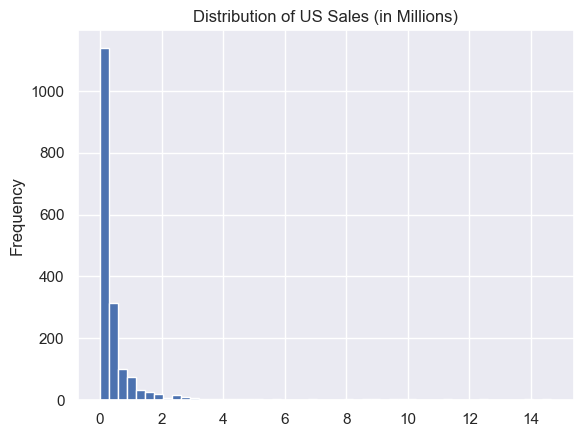

In [10]:
sales.plot.hist(bins=50, title = "Distribution of US Sales (in Millions)", x = "US Sales (in Millions)", y = "Frequency")

The numerical summary for U.S. Sales (in millions) shows that the sample includes 1,770 video games, with a mean of 0.48 million and a standard deviation of 1.06 million. The median sales value is 0.19 million, while the maximum is 14.66 million, indicating that a few games sold extremely well compared to most others. The histogram displays a strong right skewed distribution, showing that the majority of games sold fewer than 1 million copies. This suggests that only a small number of popular games dominate the market. Because of the skewed nature of the data, the median is a more appropriate measure of center than the mean, as it better represents the typical video game’s sales performance.

The null hypothesis is that the population median of the US Sales (in millions) of video games is equal to 0.19. The alternative hypothesis is that the population median of the US Sales (in millions) of video games is greater than 0.19. We will be testing this at the significance level of 0.05.

In [9]:
M = sales.median()
nullmedian = 0.19
salesnull = sales - sales.median() + nullmedian

n = len(sales)
medians = []
for i in range(5000):
    sample2 = salesnull.sample(n, replace=True)
    medians.append(sample2.median())
    sample2 = pd.DataFrame({"x": sample2})

obsmedian = sales.median()
obsmedian

mediansdf = pd.DataFrame({"x": medians})
pvalue = (mediansdf["x"] >= obsmedian).mean()
pvalue

np.float64(0.8444)

Because the p-value of 0.8494 is greater than the significance level of 0.05, we fail to reject the null hypothesis. There is not enough evidence to support the claim that the population median of U.S. Sales is less than 0.19 million.

The p-value of 0.8494 indicates that there is an 84.94% chance of obtaining a sample median larger than the one observed if the true population median of U.S. Sales is actually 0.19 million.

## 4. Conclusion

In this project, we analyzed a video game dataset to explore how different factors relate to U.S. Sales (in millions) and to examine whether certain game characteristics can predict high selling titles. Using linear regression, we investigated the relationship between YearReleased and U.S. Sales while controlling for Console, FirstPerson, and ThirdPerson. The fitted model showed only a small negative association between release year and sales, and the overall model explained very little variation in sales. We then used logistic regression to model whether a game reached high U.S. sales (Block4) based on YearReleased, Console, and FirstPerson. On the test data, the classifier achieved an accuracy of about 0.56, a sensitivity of 0.857, a specificity of 0.553, and an AUC of 0.763, suggesting that while the model has limited overall predictive power, it is fairly effective at identifying successful titles. These findings provide a basic sense of how release timing and game characteristics relate to commercial performance in this dataset.

One limitation we faced in our analysis was the extremely skewed nature of the sales data. Most games sold very little while a small number sold extremely well, which affected the linear model and contributed to violations of key regression assumptions. Another limitation is that the dataset does not include important contextual factors such as marketing budgets, publisher reputation, critic reviews, or player engagement, all of which likely influence whether a game becomes successful. The Block4 variable used in logistic regression is also a rough indicator of “high sales,” which limits the precision of the classifier. These limitations make it difficult to generalize our conclusions to the broader video game industry or to make strong claims about what truly drives sales.

Future work could expand this analysis by incorporating more recent data and adding additional predictors such as genre, marketing information, review scores, and online engagement metrics. Researchers could also explore modeling approaches that handle skewed data more effectively, such as tree-based classifiers or regularized regression methods. New questions might include whether certain consoles consistently produce more successful titles, how sales trends have shifted across console generations, or how marketing and player reviews influence long-term sales. Exploring these directions could provide deeper, more actionable insights for developers, publishers, and investors seeking to understand what contributes to commercial success in the gaming industry.